## 1. Setup & Data Preparation

In [ ]:
!pip install -q scikit-learn xgboost shap
!pip install -q tqdm
!pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    r2_score, mean_absolute_error, mean_squared_error
)
import shap
import optuna
import requests

In [ ]:
projectDf = pd.read_excel('/content/IEG_ICRR_PPAR_Ratings_2025-09-03.xlsx')
riskDf = pd.read_csv('/content/CRC_Yearly_Final_1999_2025.csv')
wgiDf = pd.read_csv("WB_WGI_r.csv")

In [ ]:
projectDf = projectDf[['Project ID','Project Name','Approval FY','IEG Outcome Ratings','Global Practice','Country','Project Volume']]
projectDf = projectDf.dropna(subset=['Project ID'])
projectDf

,Project ID,Project Name,Approval FY,IEG Outcome Ratings,Global Practice,Country,Project Volume
0,P004649,TH OZONE DEPLETING SUBS,1995.0,Satisfactory,"Environment, Natural Resources & the Blue Economy",Thailand,>=25 million & <50 million
1,P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,Moderately Satisfactory,"Environment, Natural Resources & the Blue Economy",Argentina,>=10 million & <25 million
2,P006043,AR RENEW.ENERGY R.MKTS,1999.0,Moderately Unsatisfactory,Energy & Extractives,Argentina,>=50 million & <100 million
3,P006553,BR APL Integrated Water Management In Metropol...,2010.0,Unsatisfactory,Water,Brazil,>=100 million
4,P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,Moderately Unsatisfactory,Water,Uzbekistan,>=50 million & <100 million
...,...,...,...,...,...,...,...
10735,P178224,Mexico Inclusive and Sustainable Economic Grow...,2022.0,Satisfactory,"Macroeconomics, Trade and Investment",Mexico,>=100 million
10736,P178866,Lebanon: Wheat supply emergency response project,2022.0,Satisfactory,Agriculture and Food,Lebanon,>=100 million
10737,P178989,Sudan Emergency Safety Nets Project,2023.0,Satisfactory,Social Protection & Jobs,Sudan,>=100 million
10738,P179112,Barbados Green and Resilient Recovery DPL,2023.0,Satisfactory,"Environment, Natural Resources & the Blue Economy",Barbados,>=100 million


In [ ]:
riskDf.head()

,Country,Year,CRC_Risk
0,Afghanistan,1999,7.0
1,Afghanistan,2000,NaN
2,Afghanistan,2001,NaN
3,Afghanistan,2002,NaN
4,Afghanistan,2003,NaN


In [ ]:
wgiDf.head()

,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE
0,ABW,Aruba,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,NaN
1,AFG,Afghanistan,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,-1.291705
2,AGO,Angola,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,-1.167702
3,AIA,Anguilla,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,NaN
4,ALB,Albania,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,-0.893903


## 2. Merge & Preprocessing



### (1) Merge Project DF with Risk DF





In [ ]:
projectDf_r = projectDf.merge(
    riskDf[["Country", "Year", "CRC_Risk"]],
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left").drop(columns=["Year"])

projectDf_r.head()

,Project ID,Project Name,Approval FY,IEG Outcome Ratings,Global Practice,Country,Project Volume,CRC_Risk
0,P004649,TH OZONE DEPLETING SUBS,1995.0,Satisfactory,"Environment, Natural Resources & the Blue Economy",Thailand,>=25 million & <50 million,NaN
1,P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,Moderately Satisfactory,"Environment, Natural Resources & the Blue Economy",Argentina,>=10 million & <25 million,NaN
2,P006043,AR RENEW.ENERGY R.MKTS,1999.0,Moderately Unsatisfactory,Energy & Extractives,Argentina,>=50 million & <100 million,5.0
3,P006553,BR APL Integrated Water Management In Metropol...,2010.0,Unsatisfactory,Water,Brazil,>=100 million,3.0
4,P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,Moderately Unsatisfactory,Water,Uzbekistan,>=50 million & <100 million,7.0


### (2) Merge Project DF with WGI DF


In [ ]:
wgi_est = wgiDf[wgiDf["INDICATOR_LABEL"].str.endswith("Estimate")].copy()
wgi_est = wgi_est[["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]

wgi_wide = (
    wgi_est.pivot_table(
        index=["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD"],
        columns="INDICATOR_LABEL",
        values="OBS_VALUE"
    )
    .reset_index()
)

rename_map = {
    "Control of Corruption: Estimate": "wgi_cc",
    "Government Effectiveness: Estimate": "wgi_ge",
    "Political Stability and Absence of Violence/Terrorism: Estimate": "wgi_pv",
    "Rule of Law: Estimate": "wgi_rl",
    "Regulatory Quality: Estimate": "wgi_rq",
    "Voice and Accountability: Estimate": "wgi_va"
}

wgi_clean = (
    wgi_wide.rename(columns=rename_map)
    .rename(columns={"REF_AREA": "iso3c", "REF_AREA_LABEL": "Country", "TIME_PERIOD": "year"})
    [["iso3c","Country","year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]]
)

# Copy and initial cleaning
proj = projectDf_r.copy()
wgi_use = wgi_clean.copy()

proj = proj[proj["Country"].notna()]
proj["Country"] = proj["Country"].astype(str).str.strip()
proj["Approval FY"] = pd.to_numeric(proj["Approval FY"], errors="coerce")
proj = proj.dropna(subset=["Approval FY"])

wgi_use["Country"] = wgi_use["Country"].astype(str).str.strip()
wgi_use["year"] = pd.to_numeric(wgi_use["year"], errors="coerce")
wgi_use = wgi_use.dropna(subset=["year"])

# Remove duplicates in WGI (keep last within each country–year)
wgi_use = (
    wgi_use.sort_values(["Country", "year"])
           .drop_duplicates(subset=["Country", "year"], keep="last")
           .reset_index(drop=True)
)

# Prepare keys for merge_asof
left_key = proj[["Country", "Approval FY"]].copy()
left_key["Approval FY"] = left_key["Approval FY"].astype(float)

right_key = wgi_use[
    ["Country", "year", "wgi_cc", "wgi_ge", "wgi_pv",
     "wgi_rl", "wgi_rq", "wgi_va"]
].copy()
right_key["year"] = right_key["year"].astype(float)

# Perform merge_asof for each country
parts = []

for country, group in left_key.groupby("Country"):

    wgi_country = right_key[right_key["Country"] == country]

    # No WGI records for this country → assign NaNs
    if wgi_country.empty:
        temp = group.copy()
        for col in ["wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]:
            temp[col] = np.nan
        temp["Country"] = country
        parts.append(temp)
        continue

    group_sorted = (
        group.sort_values("Approval FY")
             .rename(columns={"Approval FY": "year"})
    )

    wgi_sorted = wgi_country.sort_values("year").drop(columns=["Country"])

    merged_tmp = pd.merge_asof(
        group_sorted,
        wgi_sorted,
        on="year",
        direction="backward",
        allow_exact_matches=True
    ).rename(columns={"year": "Approval FY"})

    merged_tmp["Country"] = country
    parts.append(merged_tmp)

# Combine all asof results
matched = pd.concat(parts, ignore_index=True)

# Remove duplicates (Country + Approval FY)
matched = (
    matched.sort_values(["Country", "Approval FY"])
           .drop_duplicates(subset=["Country", "Approval FY"], keep="first")
)

# Final merge with project dataset
merged_nearest = proj.merge(
    matched,
    on=["Country", "Approval FY"],
    how="left"
)

print("Final shape:", merged_nearest.shape)
proj_filtered = merged_nearest
proj_filtered.head()

Final shape: (10726, 14)


,Project ID,Project Name,Approval FY,IEG Outcome Ratings,Global Practice,Country,Project Volume,CRC_Risk,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,P004649,TH OZONE DEPLETING SUBS,1995.0,Satisfactory,"Environment, Natural Resources & the Blue Economy",Thailand,>=25 million & <50 million,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,Moderately Satisfactory,"Environment, Natural Resources & the Blue Economy",Argentina,>=10 million & <25 million,NaN,-0.101317,0.165690,0.111377,0.075553,0.518067,0.391903
2,P006043,AR RENEW.ENERGY R.MKTS,1999.0,Moderately Unsatisfactory,Energy & Extractives,Argentina,>=50 million & <100 million,5.0,-0.203482,0.328712,-0.134650,-0.038882,0.521346,0.308850
3,P006553,BR APL Integrated Water Management In Metropol...,2010.0,Unsatisfactory,Water,Brazil,>=100 million,3.0,0.043806,-0.086863,0.013476,0.056414,0.246620,0.571349
4,P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,Moderately Unsatisfactory,Water,Uzbekistan,>=50 million & <100 million,7.0,-0.914872,-1.188411,-1.299195,-1.246617,-1.423900,-1.764603


### (3) Merge Project DF with Governance indicator(API)


In [ ]:
def fetch_wb_indicator(indicator):
    """
    Fetch a World Bank indicator for all countries, all years.
    Returns a clean DataFrame: Country, ISO3, Year, Value.
    """
    url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator}?format=json&per_page=20000"
    res = requests.get(url).json()

    records = []
    for entry in res[1]:
        country = entry["country"]["value"]
        iso = entry["country"]["id"]
        val = entry["value"]
        year = entry["date"]

        if country != "World" and val is not None:
            records.append({
                "Country": country,
                "ISO3": iso,
                "Year": int(year),
                indicator: float(val)
            })

    return pd.DataFrame(records)

gdp_pc   = fetch_wb_indicator("NY.GDP.PCAP.PP.KD")   # GDP per capita PPP
gdp_gr   = fetch_wb_indicator("NY.GDP.MKTP.KD.ZG")   # GDP Growth
infl_cpi = fetch_wb_indicator("FP.CPI.TOTL.ZG")      # Inflation

proj = proj_filtered.copy()

# Merge GDP per capita
proj = proj.merge(
    gdp_pc.rename(columns={"NY.GDP.PCAP.PP.KD": "gdp_pc"}),
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"], how="left").drop(columns=["ISO3", "Year"])

# Merge GDP growth
proj = proj.merge(
    gdp_gr.rename(columns={"NY.GDP.MKTP.KD.ZG": "gdp_growth"}),
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left").drop(columns=["ISO3", "Year"])

# Merge Inflation
proj = proj.merge(
    infl_cpi.rename(columns={"FP.CPI.TOTL.ZG": "inflation"}),
    left_on=["Country", "Approval FY"],
    right_on=["Country", "Year"],
    how="left").drop(columns=["ISO3", "Year"])

proj.head()


,Project ID,Project Name,Approval FY,IEG Outcome Ratings,Global Practice,Country,Project Volume,CRC_Risk,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va,gdp_pc,gdp_growth,inflation
0,P004649,TH OZONE DEPLETING SUBS,1995.0,Satisfactory,"Environment, Natural Resources & the Blue Economy",Thailand,>=25 million & <50 million,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11953.920383,8.120315,NaN
1,P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,Moderately Satisfactory,"Environment, Natural Resources & the Blue Economy",Argentina,>=10 million & <25 million,NaN,-0.101317,0.165690,0.111377,0.075553,0.518067,0.391903,23172.158340,8.111047,NaN
2,P006043,AR RENEW.ENERGY R.MKTS,1999.0,Moderately Unsatisfactory,Energy & Extractives,Argentina,>=50 million & <100 million,5.0,-0.203482,0.328712,-0.134650,-0.038882,0.521346,0.308850,22714.511130,-3.385457,NaN
3,P006553,BR APL Integrated Water Management In Metropol...,2010.0,Unsatisfactory,Water,Brazil,>=100 million,3.0,0.043806,-0.086863,0.013476,0.056414,0.246620,0.571349,18062.158110,7.528226,5.038727
4,P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,Moderately Unsatisfactory,Water,Uzbekistan,>=50 million & <100 million,7.0,-0.914872,-1.188411,-1.299195,-1.246617,-1.423900,-1.764603,3711.778531,4.232627,NaN


## 3. 3-Class Project Outcome Prediction




### 1) Define Target
	•	Fail (0): Outcome Score ≤ 2

	•	Moderate (1): Outcome Score = 3

	•	Success (2): Outcome Score ≥ 4


In [ ]:
proj_cls = proj.copy()


def label_outcome_3class(x):
    if x <= 2:        # 1–2 → Fail
        return 0
    elif x == 3:      # 3 → Moderate
        return 1
    else:             # 4–5 → Success
        return 2

rating_map = {
    "Highly Unsatisfactory": 0,
    "Unsatisfactory": 1,
    "Moderately Unsatisfactory": 2,
    "Moderately Satisfactory": 3,
    "Satisfactory": 4,
    "Highly Satisfactory": 5
}

proj_cls["Outcome_Score"] = proj_cls["IEG Outcome Ratings"].map(rating_map)


proj_cls["Outcome_Class3"] = proj_cls["Outcome_Score"].apply(label_outcome_3class)

###2) Feature Engineering

In [ ]:
pv_map_ordinal = {
    "Less than 10 million": 1,
    ">=10 million & <25 million": 2,
    ">=25 million & <50 million": 3,
    ">=50 million & <100 million": 4,
    ">=100 million": 5,
}


pv_map_midpoint = {
    "Less than 10 million": 5,
    ">=10 million & <25 million": 17.5,
    ">=25 million & <50 million": 37.5,
    ">=50 million & <100 million": 75,
    ">=100 million": 150,
}


proj_cls["sector"] = (proj_cls["Global Practice"].astype(str).apply(lambda x: x.split(",")[0].strip() if isinstance(x, str) else None))
proj_cls = proj_cls.drop(columns=['Global Practice'])

proj_cls["Project_Volume_Ordinal"] = proj_cls["Project Volume"].map(pv_map_ordinal)
proj_cls["Project_Volume_MidpointM"] = proj_cls["Project Volume"].map(pv_map_midpoint)
proj_cls["log_project_volume"] = np.log1p(proj_cls["Project_Volume_MidpointM"])
proj_cls = proj_cls.drop(columns=['Project Volume'])

proj_cls["log_gdp_pc"] = np.log1p(proj_cls["gdp_pc"])
proj_cls["log_gdp_growth"] = np.log1p(proj_cls["gdp_growth"])
proj_cls["log_inflation"] = np.log1p(proj_cls["inflation"])


# ------------------------
# 3. Feature List
# ------------------------
features = [
    "Approval FY",
    "CRC_Risk",
    "log_project_volume",
    "Project_Volume_Ordinal",
    "wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va",

    # Economic Indicators
    "log_gdp_pc",
    "log_gdp_growth",
    "log_inflation",

    "sector"
]

target = "Outcome_Class3"


# ------------------------
# 4. Drop NA rows
# ------------------------
df = proj_cls.dropna(subset=[target] + features).copy()

numeric_features = [f for f in features if f != "sector"]
categorical_features = ["sector"]

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 3) Preprocess for training 4 Classification Models
 - Decision Tree
 - Random Forest
 - XGBoost
 - MLP

In [ ]:
# ------------------------
# 5. Preprocessor
# ------------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


# ------------------------
# 6. Classification Models
# ------------------------
models = {

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=550,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    ),

    # BEST OPTUNA MLP VERSION
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(40, 200),    # from Optuna
        activation="relu",
        solver="adam",
        learning_rate_init=0.0012644763,
        alpha=0.0017022310,
        batch_size=256,
        max_iter=500,
        random_state=42
    )
}


# ------------------------
# 7. Train-test split
# ------------------------
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# ------------------------
# 8. Training & Evaluation
# ------------------------
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average="macro")
    f1_weighted = f1_score(y_test, pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1_macro": f1_macro,
        "F1_weighted": f1_weighted
    })

results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False)
results_df

,Model,Accuracy,F1_macro,F1_weighted
3,MLP Neural Network,0.774054,0.768431,0.773649
1,Random Forest,0.764324,0.759049,0.763849
0,Decision Tree,0.739459,0.734046,0.739465
2,XGBoost,0.676757,0.666418,0.674795


#### Optuma for RandomForest

In [ ]:
# # -----------------------------
# # Prepare Data
# # -----------------------------
# X = df[features]
# y = df[target]

# X_train, X_valid, y_train, y_valid = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # -----------------------------
# # Optuna Objective Function
# # -----------------------------
# def objective(trial):

#     n_estimators = trial.suggest_int("n_estimators", 300, 1500)
#     max_depth = trial.suggest_int("max_depth", 5, 50)
#     min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
#     min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
#     max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
#     bootstrap = trial.suggest_categorical("bootstrap", [True, False])
#     class_weight = trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"])

#     model = RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         min_samples_split=min_samples_split,
#         min_samples_leaf=min_samples_leaf,
#         max_features=max_features,
#         bootstrap=bootstrap,
#         class_weight=class_weight,
#         random_state=42,
#         n_jobs=-1
#     )

#     pipe = Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", model)
#     ])

#     pipe.fit(X_train, y_train)
#     pred = pipe.predict(X_valid)
#     f1 = f1_score(y_valid, pred, average="macro")

#     return f1

# # -----------------------------
# # Run Optimization
# # -----------------------------
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=40)

# print("Best Trial:", study.best_trial.params)

# # -----------------------------
# # Train Best Model
# # -----------------------------
# best_params = study.best_trial.params

# best_model = RandomForestClassifier(
#     **best_params,
#     random_state=42,
#     n_jobs=-1
# )

# rf_pipe = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", best_model)
# ])

# rf_pipe.fit(X_train, y_train)
# final_pred = rf_pipe.predict(X_valid)

# print("Final F1_macro:", f1_score(y_valid, final_pred, average="macro"))

#### Optuma for MLP

In [ ]:
# # -----------------------------
# # Optuna Objective
# # -----------------------------
# def objective(trial):

#     # 1) Hidden layer structure
#     n_layers = trial.suggest_int("n_layers", 1, 4)
#     layer_sizes = []
#     for i in range(n_layers):
#         units = trial.suggest_int(f"n_units_l{i}", 32, 512)
#         layer_sizes.append(units)

#     # 2) Activation
#     activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])

#     # 3) Optimizer
#     solver = trial.suggest_categorical("solver", ["adam", "sgd"])

#     # 4) Learning rate
#     learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-4, 1e-2)

#     # 5) L2 Regularization
#     alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2)

#     # 6) Batch size
#     batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])

#     model = MLPClassifier(
#         hidden_layer_sizes=tuple(layer_sizes),
#         activation=activation,
#         solver=solver,
#         learning_rate_init=learning_rate_init,
#         alpha=alpha,
#         batch_size=batch_size,
#         max_iter=500,
#         random_state=42
#     )

#     pipe = Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", model)
#     ])

#     pipe.fit(X_train, y_train)
#     pred = pipe.predict(X_test)

#     # macro F1 based
#     f1 = f1_score(y_test, pred, average="macro")
#     return f1


# # -----------------------------
# # Run Optuna Search
# # -----------------------------
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30)

# print("Best Params:", study.best_params)
# print("Best F1 Score (macro):", study.best_value)

## 4. Best Model SHAP Explanation (MLP)

In [ ]:
# ============================================================
# 8) MLP + Calibration
# ============================================================
mlp_base = MLPClassifier(
    hidden_layer_sizes=(40, 200),
    activation="relu",
    solver="adam",
    learning_rate_init=0.0012644763,
    alpha=0.0017022310,
    batch_size=256,
    max_iter=500,
    random_state=42
)

mlp_calibrated = CalibratedClassifierCV(
    mlp_base,
    cv=3,
    method="isotonic"
)

mlp_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", mlp_calibrated)
])

# ============================================================
# 9) Train Model
# ============================================================
mlp_pipe.fit(X_train, y_train)

print("training complete.")

# ============================================================
# 10) Prepare SHAP Inputs
# ============================================================
X_test_trans = mlp_pipe.named_steps["preprocessor"].transform(X_test)

n_samples = min(200, X_test_trans.shape[0])
idx = np.random.choice(X_test_trans.shape[0], n_samples, replace=False)
X_sample = X_test_trans[idx]

# Background sample for Kernel SHAP
background = X_sample[:50]

# ============================================================
# 11) Compute SHAP Values per Class
# ============================================================
shap_values_per_class = []

for c in range(3):
    print(f"[SHAP] Computing class {c}... (0=Fail, 1=Moderate, 2=Success)")

    f = lambda x: mlp_pipe.named_steps["model"].predict_proba(x)[:, c]

    explainer_c = shap.KernelExplainer(f, background)
    sv = explainer_c.shap_values(X_sample)   # shape = (n_samples, n_features)

    shap_values_per_class.append(sv)

print("SHAP computation complete.")

training complete.
[SHAP] Computing class 0... (0=Fail, 1=Moderate, 2=Success)


  0%|          | 0/200 [00:00<?, ?it/s]

[SHAP] Computing class 1... (0=Fail, 1=Moderate, 2=Success)


  0%|          | 0/200 [00:00<?, ?it/s]

[SHAP] Computing class 2... (0=Fail, 1=Moderate, 2=Success)


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP computation complete.


In [ ]:
# with open("shap_full.pkl", "wb") as f:
#     pickle.dump({
#         "shap_values": shap_values_per_class,
#         "X_sample": X_sample,
#         "background": background,
#         "features": features
#     }, f)

# print("Full SHAP saved.")

with open("shap_full.pkl", "rb") as f:
    saved = pickle.load(f)

shap_values_per_class = saved["shap_values"]
X_sample = saved["X_sample"]
background = saved["background"]
features = saved["features"]

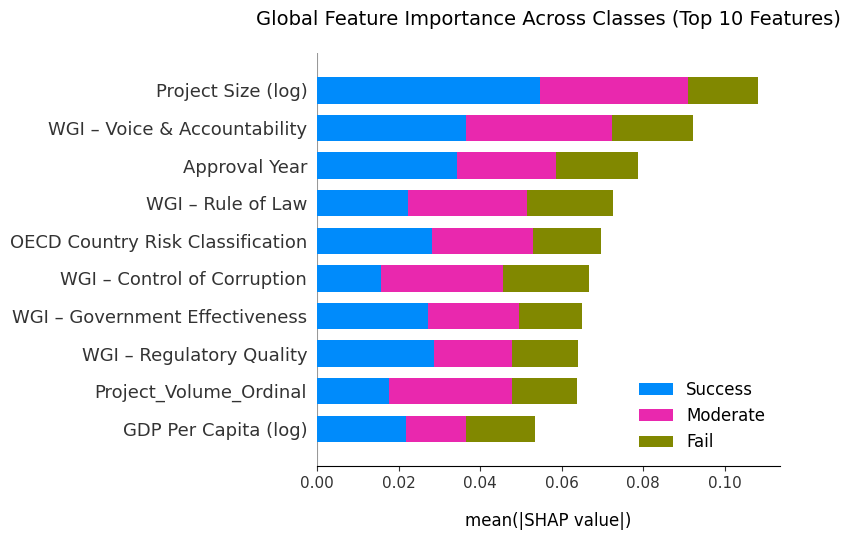


=== SHAP Beeswarm for Class: Fail ===


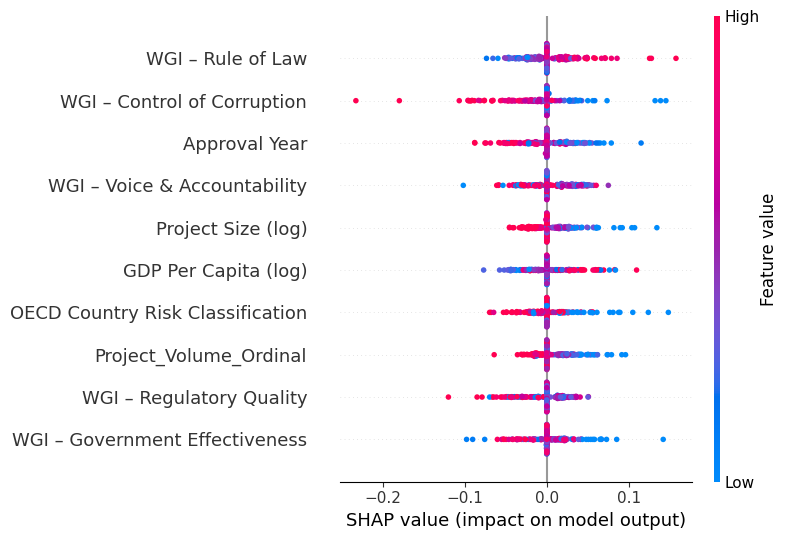


=== SHAP Beeswarm for Class: Moderate ===


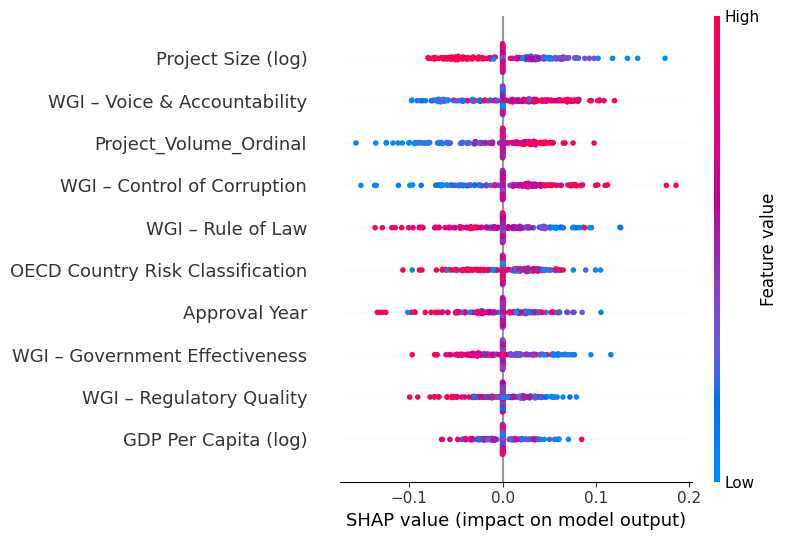


=== SHAP Beeswarm for Class: Success ===


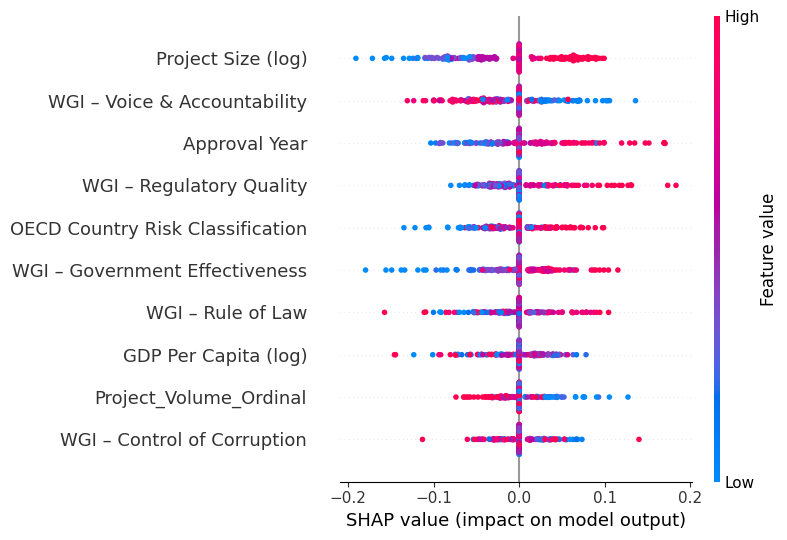

In [ ]:
# ============================================================
# 12) Feature name Transform
# ============================================================

feature_long_names = {
    "wgi_cc": "WGI – Control of Corruption",
    "wgi_ge": "WGI – Government Effectiveness",
    "wgi_pv": "WGI – Political Stability",
    "wgi_rl": "WGI – Rule of Law",
    "wgi_rq": "WGI – Regulatory Quality",
    "wgi_va": "WGI – Voice & Accountability",
    "Approval FY": "Approval Year",
    "CRC_Risk": "OECD Country Risk Classification",
    "log_project_volume": "Project Size (log)",
    "log_gdp_pc": "GDP Per Capita (log)",
    "log_gdp_growth": "GDP Growth (log)",
    "log_inflation": "Inflation (log)",
}

feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
)

feature_names_readable = [feature_long_names.get(f, f) for f in feature_names]


# ============================================================
# 13) Top-10 Feature Selection (multiclass SHAP)
# ============================================================

mean_shap = np.mean(
    np.abs(shap_values_per_class[0]) +
    np.abs(shap_values_per_class[1]) +
    np.abs(shap_values_per_class[2]),
    axis=0
)

top_k = 10
top_idx = np.argsort(mean_shap)[-top_k:]
top_idx_sorted = np.sort(top_idx)

feature_names_top = np.array(feature_names_readable)[top_idx_sorted]

X_sample_shap = X_sample[:, top_idx_sorted]

shap_values_top = [
    sv[:, top_idx_sorted] for sv in shap_values_per_class
]

assert X_sample_shap.shape[1] == shap_values_top[0].shape[1]


# ============================================================
# 14) SHAP Summary Bar (Global Importance)
# ============================================================

plt.figure(figsize=(11, 6))

shap.summary_plot(
    shap_values_top,
    X_sample_shap,
    feature_names=feature_names_top,
    class_names=["Fail","Moderate","Success"],
    plot_type="bar",
    max_display=10,
    show=False    # ← 제목 넣기 위해 True로 안 함
)

plt.title("Global Feature Importance Across Classes (Top 10 Features)", fontsize=14, pad=20)
plt.xlabel("mean(|SHAP value|)", fontsize=12, labelpad=15)

plt.tight_layout()
plt.show()

# ============================================================
# 15) Class-wise Beeswarm (Fail / Moderate / Success)
# ============================================================

for i, cname in enumerate(["Fail","Moderate","Success"]):
    print(f"\n=== SHAP Beeswarm for Class: {cname} ===")
    shap.summary_plot(
        shap_values_top[i],
        X_sample_shap,
        feature_names=feature_names_top,
        max_display=10
    )

## 5. Interaction Analysis Between Rule of Law and Other Features
- To identify which variables most strongly interact with Rule of Law (WGI – Rule of Law) in shaping failure predictions, the SHAP contribution of each feature was combined with the SHAP value of Rule of Law.

In [ ]:
# SHAP values for the Fail class (class index = 0)
shap_fail = shap_values_top[0]      # shape: (num_samples, num_features)

# Locate the index of the “Rule of Law” feature
rol_idx = feature_names_top.tolist().index("WGI – Rule of Law")


# =====================================================
# 1) Compute interaction strength: ROL × each feature
#    (Interaction = mean |SHAP_ROL + SHAP_feature|)
# =====================================================
interaction_scores = {}

for i, fname in enumerate(feature_names_top):

    # skip the ROL feature itself
    if i == rol_idx:
        continue

    interaction_strength = np.mean(
        np.abs(shap_fail[:, rol_idx] + shap_fail[:, i])
    )

    interaction_scores[fname] = interaction_strength


# Convert to DataFrame for readability
interaction_df = (
    pd.DataFrame.from_dict(interaction_scores, orient="index", columns=["Interaction"])
      .sort_values("Interaction", ascending=False)
)

display(interaction_df)

,Interaction
Approval Year,0.034838
OECD Country Risk Classification,0.034399
GDP Per Capita (log),0.033136
Project Size (log),0.031023
Project_Volume_Ordinal,0.030542
WGI – Voice & Accountability,0.029481
WGI – Government Effectiveness,0.028810
WGI – Control of Corruption,0.027465
WGI – Regulatory Quality,0.026630


## 6. Interaction Visualization Between Rule of Law and Other Key Features
	•	x-axis: Raw value of Rule of Law
	•	y-axis: Combined SHAP impact (ROL + feature)
	•	Horizontal zero-line distinguishes positive vs negative failure contribution

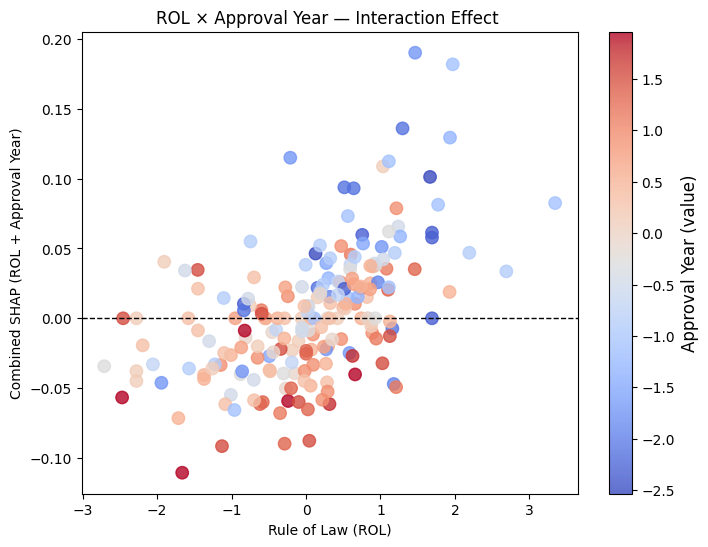

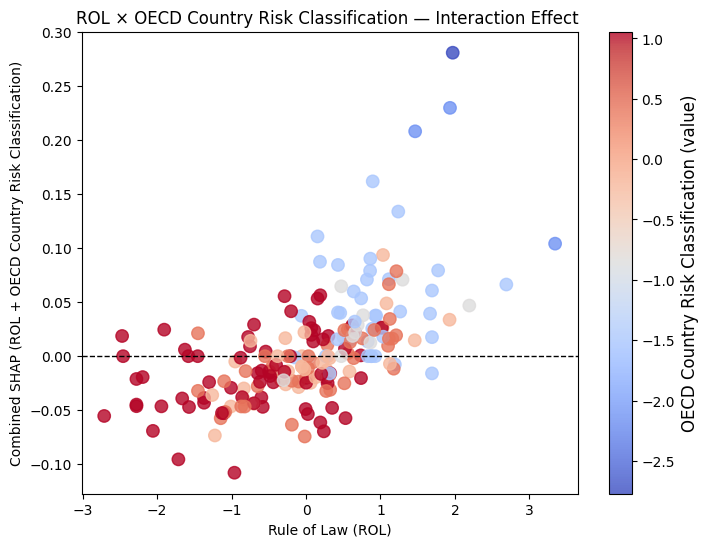

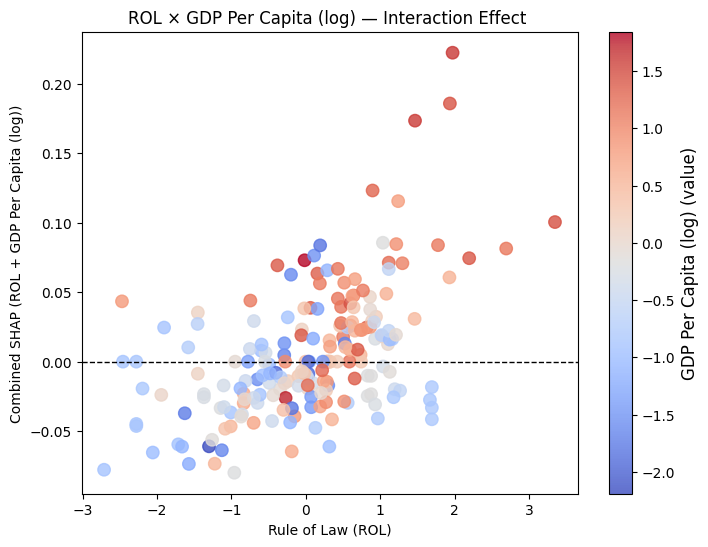

In [ ]:
def plot_interaction(feature_name):

    i = feature_names_top.tolist().index(feature_name)
    combined_shap = shap_fail[:, rol_idx] + shap_fail[:, i]

    plt.figure(figsize=(8,6))
    plt.scatter(
        X_sample_shap[:, rol_idx],
        combined_shap,
        c=X_sample_shap[:, i],
        cmap="coolwarm",
        s=80,
        alpha=0.8
    )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)

    plt.xlabel("Rule of Law (ROL)")
    plt.ylabel(f"Combined SHAP (ROL + {feature_name})")
    plt.title(f"ROL × {feature_name} — Interaction Effect ")

    cbar = plt.colorbar()
    cbar.set_label(f"{feature_name} (value)", fontsize=12)

    plt.show()


top3_features = interaction_df.index[:3]

for fname in top3_features:
    plot_interaction(fname)

## 7. Interpretation of Interaction Results: Why Similar High-Risk Projects Diverge


Even when projects share similar high-risk conditions—such as **low Rule of Law(around -1)** and **high OECD Country Risk (7)**—their predicted outcomes can diverge.  
This is because the model evaluates **interactions**, not single variables in isolation.

**Key Points:**

- **Low ROL alone does not determine failure** — its impact depends on other factors.
- **Economic strength(GDP per Capital) can offset governance weakness**, making success more likely.
- **Approval Year captures contextual improvements** (policy, capacity, systems).
- **Sector differences** influence how sensitive a project is to weak governance.

**In essence:**  
Two projects can look equally risky on the surface, but their *feature combinations* create very different risk profiles. Interaction-aware ML models reveal these nuanced differences, enabling more accurate and fair project risk assessment.

In [ ]:
def warn_for_single_project(project_row, model_pipe, feature_names_readable, top_k=5):
    """
    Generate a probability prediction and SHAP-based risk explanation
    for a single project instance.
    """

    # ---------------------------------------
    # 1) Predict class probabilities
    # ---------------------------------------
    probs = model_pipe.predict_proba(project_row)[0]
    fail_p, mod_p, succ_p = probs

    print("==== Prediction ====")
    print(f"Fail Probability:      {fail_p:.3f}")
    print(f"Moderate Probability:  {mod_p:.3f}")
    print(f"Success Probability:   {succ_p:.3f}\n")

    # ---------------------------------------
    # 2) Preprocess the input row
    # ---------------------------------------
    X_proc = model_pipe.named_steps["preprocessor"].transform(project_row)

    # Background sample: random 50 rows from training data
    # (Used by Kernel SHAP for local approximation stability)
    bg_idx = np.random.choice(len(X_train), size=min(50, len(X_train)), replace=False)
    background = model_pipe.named_steps["preprocessor"].transform(X_train.iloc[bg_idx])

    # ---------------------------------------
    # 3) Compute SHAP for the "Fail" class (class = 0)
    # ---------------------------------------
    f_fail = lambda x: model_pipe.named_steps["model"].predict_proba(x)[:, 0]

    explainer = shap.KernelExplainer(f_fail, background)
    shap_values = explainer.shap_values(X_proc)[0]   # shape = (n_features,)

    # ---------------------------------------
    # 4) Rank SHAP absolute values
    # ---------------------------------------
    shap_abs = np.abs(shap_values)
    top_idx = np.argsort(shap_abs)[-top_k:][::-1]

    print("==== Top Contributing Factors (Fail Risk) ====")
    for idx in top_idx:
        fname = feature_names_readable[idx]
        sval = shap_values[idx]
        effect = "⬆ increases fail risk" if sval > 0 else "⬇ decreases fail risk"
        print(f"{fname:40s} | SHAP = {sval:+.4f} | {effect}")

    # ---------------------------------------
    # 5) Human-friendly risk warning
    # ---------------------------------------
    print("\n==== Risk Warning ====")

    if fail_p > 0.7:
        print(" The project has a **high probability of failure**. "
              "The following factors require urgent attention:")
    elif fail_p > 0.4:
        print(" The project has a **moderate level of failure risk**. "
              "Review the following contributing factors:")
    else:
        print("✓ Failure risk is relatively low, but the following factors "
              "should still be monitored:")

    for idx in top_idx:
        fname = feature_names_readable[idx]
        sval = shap_values[idx]

        if sval > 0:
            print(f"  • {fname}: contributes positively to failure probability (↑)")
        else:
            print(f"  • {fname}: contributes toward success but remains influential (↓)")

In [ ]:
rol_threshold = -1      # "low" ROL
risk_threshold = 6      # "high" OECD Country Risk

# filtering
subset = df[(df["wgi_rl"] < rol_threshold) & (df["CRC_Risk"] > risk_threshold)]

subset.iloc[[1, 6]][["IEG Outcome Ratings", "wgi_rl", "CRC_Risk"]]

,IEG Outcome Ratings,wgi_rl,CRC_Risk
63,Moderately Unsatisfactory,-1.066578,7.0
188,Satisfactory,-1.182174,7.0


In [ ]:
df.iloc[[21]][features]

,Approval FY,CRC_Risk,log_project_volume,Project_Volume_Ordinal,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va,log_gdp_pc,log_gdp_growth,log_inflation,sector
63,2003.0,7.0,2.917771,2.0,-1.147746,-1.142073,-1.099492,-1.066578,-1.08949,-1.149909,7.460283,2.484907,2.850908,Education


In [ ]:
single_project = df.iloc[[21]][features]
warn_for_single_project(single_project, mlp_pipe, feature_names_readable)

==== Prediction ====
Fail Probability:      0.689
Moderate Probability:  0.201
Success Probability:   0.110



  0%|          | 0/1 [00:00<?, ?it/s]

==== Top Contributing Factors (Fail Risk) ====
Approval Year                            | SHAP = +0.1384 | ⬆ increases fail risk
GDP Growth (log)                         | SHAP = +0.0956 | ⬆ increases fail risk
sector_Education                         | SHAP = +0.0726 | ⬆ increases fail risk
WGI – Control of Corruption              | SHAP = +0.0501 | ⬆ increases fail risk
WGI – Political Stability                | SHAP = +0.0341 | ⬆ increases fail risk

==== Risk Warning ====
 The project has a **moderate level of failure risk**. Review the following contributing factors:
  • Approval Year: contributes positively to failure probability (↑)
  • GDP Growth (log): contributes positively to failure probability (↑)
  • sector_Education: contributes positively to failure probability (↑)
  • WGI – Control of Corruption: contributes positively to failure probability (↑)
  • WGI – Political Stability: contributes positively to failure probability (↑)


In [ ]:
df.iloc[[67]][features]

,Approval FY,CRC_Risk,log_project_volume,Project_Volume_Ordinal,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va,log_gdp_pc,log_gdp_growth,log_inflation,sector
188,2006.0,7.0,3.650658,3.0,-1.042832,-1.072458,-1.386145,-1.182174,-1.106147,-1.351941,7.632541,2.079442,2.398883,Urban


In [ ]:
single_project = df.iloc[[67]][features]
warn_for_single_project(single_project, mlp_pipe, feature_names_readable)

==== Prediction ====
Fail Probability:      0.089
Moderate Probability:  0.189
Success Probability:   0.722



  0%|          | 0/1 [00:00<?, ?it/s]

==== Top Contributing Factors (Fail Risk) ====
GDP Per Capita (log)                     | SHAP = -0.0506 | ⬇ decreases fail risk
OECD Country Risk Classification         | SHAP = -0.0415 | ⬇ decreases fail risk
WGI – Rule of Law                        | SHAP = -0.0359 | ⬇ decreases fail risk
sector_Urban                             | SHAP = -0.0347 | ⬇ decreases fail risk
WGI – Voice & Accountability             | SHAP = -0.0231 | ⬇ decreases fail risk

==== Risk Warning ====
✓ Failure risk is relatively low, but the following factors should still be monitored:
  • GDP Per Capita (log): contributes toward success but remains influential (↓)
  • OECD Country Risk Classification: contributes toward success but remains influential (↓)
  • WGI – Rule of Law: contributes toward success but remains influential (↓)
  • sector_Urban: contributes toward success but remains influential (↓)
  • WGI – Voice & Accountability: contributes toward success but remains influential (↓)
